# Inverse Hessian-Vector Products and Newton Optimization

This tutorial covers advanced automatic differentiation techniques:

1. **Hessian-Vector Products (HVP)**: Compute H·v without forming H
2. **Conjugate Gradient (CG)**: Solve linear systems iteratively
3. **Inverse HVP**: Compute H⁻¹·v using CG with HVPs
4. **Newton Optimization**: Second-order optimization using inverse HVP

## Why This Matters

Newton's method for optimization computes:
$$x_{k+1} = x_k - H^{-1} \nabla f$$

But forming and inverting H is O(n³). Using inverse HVP, we can compute the Newton step in O(n) per iteration!

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
from jax import grad, jvp, hessian
from jax.scipy.sparse.linalg import cg
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.8.1


## 1. Review: Hessian-Vector Product (HVP)

The HVP computes H·v without forming the full Hessian:

$$H \cdot v = \frac{\partial}{\partial x}(\nabla f \cdot v)$$

This uses forward-over-reverse mode: `jvp` of `grad`.

In [2]:
def hvp(f, x, v):
    """Hessian-vector product: H·v
    
    Computes H·v without forming H explicitly.
    Cost: O(n) - same as one gradient evaluation.
    """
    return jvp(grad(f), (x,), (v,))[1]


# Test function: Rosenbrock (classic optimization benchmark)
def rosenbrock(x):
    """f(x,y) = (1-x)² + 100(y-x²)²
    
    Minimum at (1, 1) with f(1,1) = 0.
    Has a curved valley that's hard to optimize.
    """
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2


x = jnp.array([0.0, 0.0])
v = jnp.array([1.0, 0.0])

# Compute HVP
hv = hvp(rosenbrock, x, v)
print(f"x = {x}")
print(f"v = {v}")
print(f"H·v = {hv}")

# Verify against full Hessian
H = hessian(rosenbrock)(x)
print(f"\nFull Hessian:\n{H}")
print(f"H @ v = {H @ v}  (should match H·v)")

Metal device set to: Apple M4 Pro
x = [0. 0.]
v = [1. 0.]
H·v = [2. 0.]


W0000 00:00:1765415903.641734 7212034 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765415903.650953 7212034 service.cc:145] XLA service 0x600003d21300 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765415903.650961 7212034 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765415903.651906 7212034 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765415903.651913 7212034 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.



Full Hessian:
[[  2.   0.]
 [  0. 200.]]
H @ v = [2. 0.]  (should match H·v)


## 2. Conjugate Gradient (CG) Algorithm

CG solves the linear system $A \cdot x = b$ iteratively, using only matrix-vector products.

### Algorithm

```
Initialize: x₀ = 0, r₀ = b, p₀ = r₀

For k = 0, 1, 2, ...
    αₖ = (rₖᵀrₖ) / (pₖᵀ A pₖ)     # step size
    xₖ₊₁ = xₖ + αₖ pₖ              # update solution
    rₖ₊₁ = rₖ - αₖ A pₖ            # update residual  
    βₖ = (rₖ₊₁ᵀrₖ₊₁) / (rₖᵀrₖ)    # conjugacy parameter
    pₖ₊₁ = rₖ₊₁ + βₖ pₖ            # update search direction
```

**Key property:** Only needs one A·v product per iteration!

In [3]:
def cg_solve(A_matvec, b, x0=None, maxiter=100, tol=1e-10):
    """Conjugate Gradient solver.
    
    Solves A·x = b where A is symmetric positive definite.
    
    Args:
        A_matvec: Function computing A·v
        b: Right-hand side vector
        x0: Initial guess (default: zeros)
        maxiter: Maximum iterations
        tol: Convergence tolerance
    
    Returns:
        x: Solution
        info: Dictionary with convergence info
    """
    n = len(b)
    x = jnp.zeros(n) if x0 is None else x0
    r = b - A_matvec(x)  # residual
    p = r.copy()          # search direction
    rs_old = jnp.dot(r, r)
    
    residuals = [float(jnp.sqrt(rs_old))]
    
    for i in range(maxiter):
        Ap = A_matvec(p)
        alpha = rs_old / jnp.dot(p, Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = jnp.dot(r, r)
        
        residuals.append(float(jnp.sqrt(rs_new)))
        
        if jnp.sqrt(rs_new) < tol:
            break
            
        beta = rs_new / rs_old
        p = r + beta * p
        rs_old = rs_new
    
    return x, {'iterations': i+1, 'residuals': residuals}


# Example: Solve a simple linear system
A = jnp.array([[4., 1.], [1., 3.]])
b = jnp.array([1., 2.])

# Solve using our CG implementation
x_cg, info = cg_solve(lambda v: A @ v, b)

print(f"System: A·x = b")
print(f"A = \n{A}")
print(f"b = {b}")
print(f"\nCG solution: x = {x_cg}")
print(f"Iterations: {info['iterations']}")
print(f"\nVerification: A·x = {A @ x_cg}")
print(f"Direct solve: x = {jnp.linalg.solve(A, b)}")

System: A·x = b
A = 
[[4. 1.]
 [1. 3.]]
b = [1. 2.]

CG solution: x = [0.09090909 0.63636364]
Iterations: 2

Verification: A·x = [1. 2.]
Direct solve: x = [0.09090909 0.63636364]


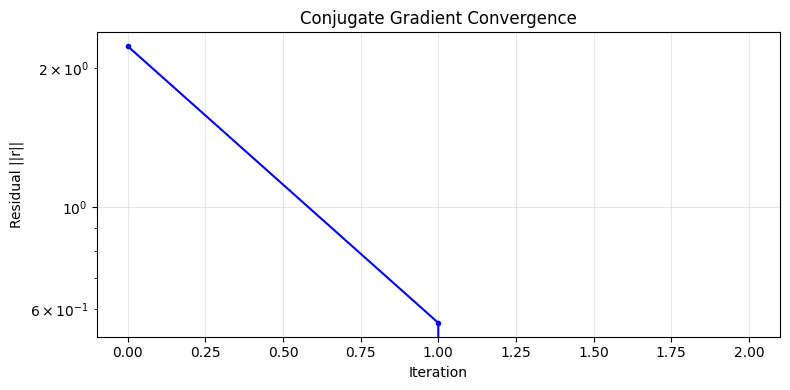

In [4]:
# Visualize CG convergence
plt.figure(figsize=(8, 4))
plt.semilogy(info['residuals'], 'b.-')
plt.xlabel('Iteration')
plt.ylabel('Residual ||r||')
plt.title('Conjugate Gradient Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Inverse Hessian-Vector Product (IHVP)

The **inverse HVP** computes $H^{-1} \cdot v$ by solving:

$$H \cdot x = v \quad \Rightarrow \quad x = H^{-1} \cdot v$$

Using CG with HVPs, we never form or invert H!

In [5]:
def ihvp(f, x, v, maxiter=50, tol=1e-8):
    """Inverse Hessian-vector product: H⁻¹·v
    
    Computes H⁻¹·v without forming or inverting H.
    Uses CG with HVPs internally.
    
    Args:
        f: Scalar function
        x: Point at which to evaluate Hessian
        v: Vector to multiply by H⁻¹
        maxiter: Maximum CG iterations
        tol: Convergence tolerance
    
    Returns:
        H⁻¹·v
    """
    # Define the Hessian-vector product operator
    def hvp_op(u):
        return hvp(f, x, u)
    
    # Solve H·result = v using CG
    result, _ = cg(hvp_op, v, maxiter=maxiter, tol=tol)
    return result


# Test inverse HVP
x = jnp.array([0.5, 0.5])
v = jnp.array([1.0, 2.0])

# Compute H⁻¹·v using our function
ihv = ihvp(rosenbrock, x, v)
print(f"x = {x}")
print(f"v = {v}")
print(f"H⁻¹·v = {ihv}")

# Verify against explicit inverse
H = hessian(rosenbrock)(x)
H_inv = jnp.linalg.inv(H)
print(f"\nFull Hessian:\n{H}")
print(f"\nExplicit H⁻¹·v = {H_inv @ v}  (should match)")

# Double-check: H·(H⁻¹·v) should equal v
print(f"\nVerification: H·(H⁻¹·v) = {hvp(rosenbrock, x, ihv)}")
print(f"Original v = {v}")

x = [0.5 0.5]
v = [1. 2.]
H⁻¹·v = [-0.03061224 -0.02061224]

Full Hessian:
[[ 102. -200.]
 [-200.  200.]]

Explicit H⁻¹·v = [-0.03061224 -0.02061224]  (should match)

Verification: H·(H⁻¹·v) = [1. 2.]
Original v = [1. 2.]


## 4. Newton Optimization

Newton's method uses the update:

$$x_{k+1} = x_k - H^{-1} \nabla f = x_k + \delta$$

where the Newton step $\delta = -H^{-1} \nabla f$ is computed via inverse HVP.

### Comparison:
- **Gradient descent**: Uses only first-order info, slow near minimum
- **Newton's method**: Uses curvature (second-order), fast convergence

In [6]:
def newton_step(f, x):
    """Compute Newton step: δ = -H⁻¹·∇f"""
    g = grad(f)(x)
    return -ihvp(f, x, g)


def gradient_descent_step(f, x, lr=0.001):
    """Compute gradient descent step: δ = -lr·∇f"""
    g = grad(f)(x)
    return -lr * g


def optimize(f, x0, step_fn, n_steps=50):
    """Run optimization and track trajectory."""
    trajectory = [x0]
    x = x0
    for _ in range(n_steps):
        delta = step_fn(f, x)
        x = x + delta
        trajectory.append(x)
    return jnp.array(trajectory)


# Starting point
x0 = jnp.array([-1.0, 1.0])

# Run both optimizers
traj_newton = optimize(rosenbrock, x0, newton_step, n_steps=20)
traj_gd = optimize(rosenbrock, x0, 
                   lambda f, x: gradient_descent_step(f, x, lr=0.002), 
                   n_steps=500)

print(f"Starting point: {x0}")
print(f"True minimum: [1, 1]")
print(f"\nNewton (20 steps): {traj_newton[-1]}")
print(f"GD (500 steps):    {traj_gd[-1]}")

Starting point: [-1.  1.]
True minimum: [1, 1]

Newton (20 steps): [1. 1.]
GD (500 steps):    [0.36390293 0.1293884 ]


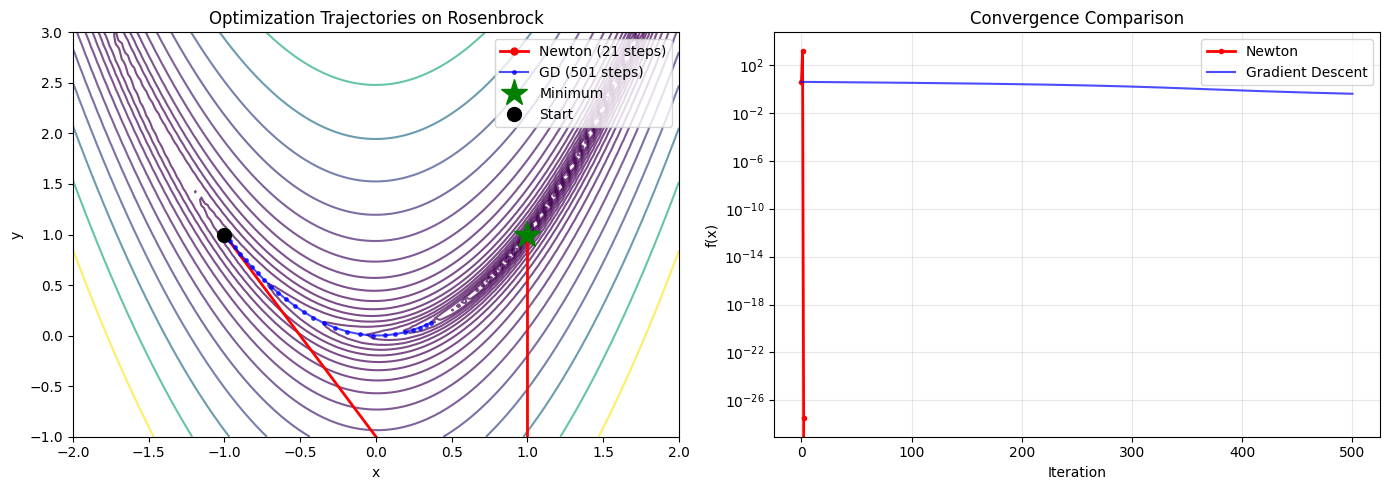

In [7]:
# Visualize optimization trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create contour plot
x_range = jnp.linspace(-2, 2, 100)
y_range = jnp.linspace(-1, 3, 100)
X, Y = jnp.meshgrid(x_range, y_range)
Z = jnp.array([[rosenbrock(jnp.array([xi, yi])) 
                for xi, yi in zip(x_row, y_row)] 
               for x_row, y_row in zip(X, Y)])

# Plot 1: Trajectories on contour
ax1 = axes[0]
ax1.contour(X, Y, Z, levels=jnp.logspace(-1, 3, 20), cmap='viridis', alpha=0.7)
ax1.plot(traj_newton[:, 0], traj_newton[:, 1], 'r.-', 
         label=f'Newton ({len(traj_newton)} steps)', markersize=10, linewidth=2)
ax1.plot(traj_gd[::20, 0], traj_gd[::20, 1], 'b.-', 
         label=f'GD ({len(traj_gd)} steps)', markersize=5, alpha=0.7)
ax1.plot(1, 1, 'g*', markersize=20, label='Minimum')
ax1.plot(x0[0], x0[1], 'ko', markersize=10, label='Start')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Optimization Trajectories on Rosenbrock')
ax1.legend()
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 3)

# Plot 2: Convergence
ax2 = axes[1]
f_newton = [float(rosenbrock(x)) for x in traj_newton]
f_gd = [float(rosenbrock(x)) for x in traj_gd]
ax2.semilogy(f_newton, 'r.-', label='Newton', linewidth=2)
ax2.semilogy(f_gd, 'b-', label='Gradient Descent', alpha=0.7)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('f(x)')
ax2.set_title('Convergence Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<cell_type>markdown</cell_type>## 5. Scaling: IHVP vs Naive Hessian Inverse

For large problems, explicit Hessian operations become prohibitive:

| Operation | Time Complexity | Memory |
|-----------|-----------------|--------|
| Form H | O(n²) | O(n²) |
| Invert H (or solve) | O(n³) | O(n²) |
| Single HVP | O(n) | O(n) |
| IHVP via CG (k iters) | O(kn) | O(n) |

**Key insight:** The explicit method requires storing the full n×n Hessian matrix, while IHVP only needs a few vectors.

For n = 10,000 parameters:
- Hessian storage: 800 MB (10,000² × 8 bytes)
- IHVP storage: ~0.8 MB (just vectors)

**When does IHVP win?**
- Small n (< 500): Explicit method is faster due to optimized BLAS
- Large n (> 1000): IHVP wins on both time (O(kn) vs O(n³)) and memory (O(n) vs O(n²))
- Memory-constrained: IHVP is essential when Hessian doesn't fit in memory

In [8]:
import time
import tracemalloc

def benchmark_with_memory(n, n_trials=3):
    """Benchmark IHVP vs explicit inverse for dimension n.
    
    Returns timing and peak memory usage for both methods.
    """
    # Create a quadratic function with random Hessian
    key = jax.random.PRNGKey(42)
    A = jax.random.normal(key, (n, n))
    A = A @ A.T + jnp.eye(n)  # Make positive definite
    
    def quadratic(x):
        return 0.5 * x @ A @ x
    
    x = jnp.ones(n)
    v = jnp.ones(n)
    
    # Warm up JIT
    _ = ihvp(quadratic, x, v)
    _ = ihvp(quadratic, x, v)
    
    # Benchmark IHVP
    tracemalloc.start()
    start = time.time()
    for _ in range(n_trials):
        result_ihvp = ihvp(quadratic, x, v)
        result_ihvp.block_until_ready()  # Ensure computation completes
    time_ihvp = (time.time() - start) / n_trials
    _, peak_ihvp = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # Benchmark explicit method (form H, then solve)
    if n <= 3000:  # Skip for very large n
        # Warm up
        H = hessian(quadratic)(x)
        _ = jnp.linalg.solve(H, v)
        
        tracemalloc.start()
        start = time.time()
        for _ in range(n_trials):
            H = hessian(quadratic)(x)
            result_explicit = jnp.linalg.solve(H, v)
            result_explicit.block_until_ready()
        time_explicit = (time.time() - start) / n_trials
        _, peak_explicit = tracemalloc.get_traced_memory()
        tracemalloc.stop()
    else:
        time_explicit = None
        peak_explicit = None
    
    # Theoretical memory for Hessian: n² floats × 8 bytes
    hessian_memory = n * n * 8
    
    return {
        'n': n,
        'time_ihvp': time_ihvp,
        'time_explicit': time_explicit,
        'mem_ihvp': peak_ihvp,
        'mem_explicit': peak_explicit,
        'mem_hessian_theory': hessian_memory,
    }


# Run benchmarks for increasing problem sizes
print("Running benchmarks (this may take a minute)...")
print()

sizes = [100, 500, 1000, 1500, 2000, 2500, 3000]
results = []

for n in sizes:
    print(f"  n = {n}...", end=" ", flush=True)
    res = benchmark_with_memory(n)
    results.append(res)
    print("done")

print()
print("=" * 80)
print(f"{'n':>6} | {'IHVP (ms)':>10} | {'Explicit (ms)':>13} | {'Speedup':>8} | {'H memory':>10}")
print("=" * 80)

for r in results:
    t_i = r['time_ihvp'] * 1000
    t_e = r['time_explicit'] * 1000 if r['time_explicit'] else float('nan')
    speedup = r['time_explicit'] / r['time_ihvp'] if r['time_explicit'] else float('nan')
    mem_h = r['mem_hessian_theory'] / 1e6  # MB
    
    if r['time_explicit']:
        marker = " <-- IHVP wins!" if speedup > 1 else ""
        print(f"{r['n']:>6} | {t_i:>10.1f} | {t_e:>13.1f} | {speedup:>7.2f}x | {mem_h:>8.1f} MB{marker}")
    else:
        print(f"{r['n']:>6} | {t_i:>10.1f} | {'N/A':>13} | {'N/A':>8} | {mem_h:>8.1f} MB")

print("=" * 80)
print("\nNote: IHVP has constant overhead from CG iterations, but scales as O(kn)")
print("      Explicit scales as O(n²) for Hessian formation + O(n³) for solve")

Running benchmarks (this may take a minute)...

  n = 100... done
  n = 500... done
  n = 1000... done
  n = 1500... done
  n = 2000... done
  n = 2500... done
  n = 3000... done

     n |  IHVP (ms) | Explicit (ms) |  Speedup |   H memory
   100 |       67.8 |          12.6 |    0.19x |      0.1 MB
   500 |       68.1 |          15.9 |    0.23x |      2.0 MB
  1000 |       70.8 |          22.4 |    0.32x |      8.0 MB
  1500 |       76.5 |          50.3 |    0.66x |     18.0 MB
  2000 |       84.6 |          98.5 |    1.16x |     32.0 MB <-- IHVP wins!
  2500 |       98.1 |         195.2 |    1.99x |     50.0 MB <-- IHVP wins!
  3000 |      111.7 |         300.4 |    2.69x |     72.0 MB <-- IHVP wins!

Note: IHVP has constant overhead from CG iterations, but scales as O(kn)
      Explicit scales as O(n²) for Hessian formation + O(n³) for solve


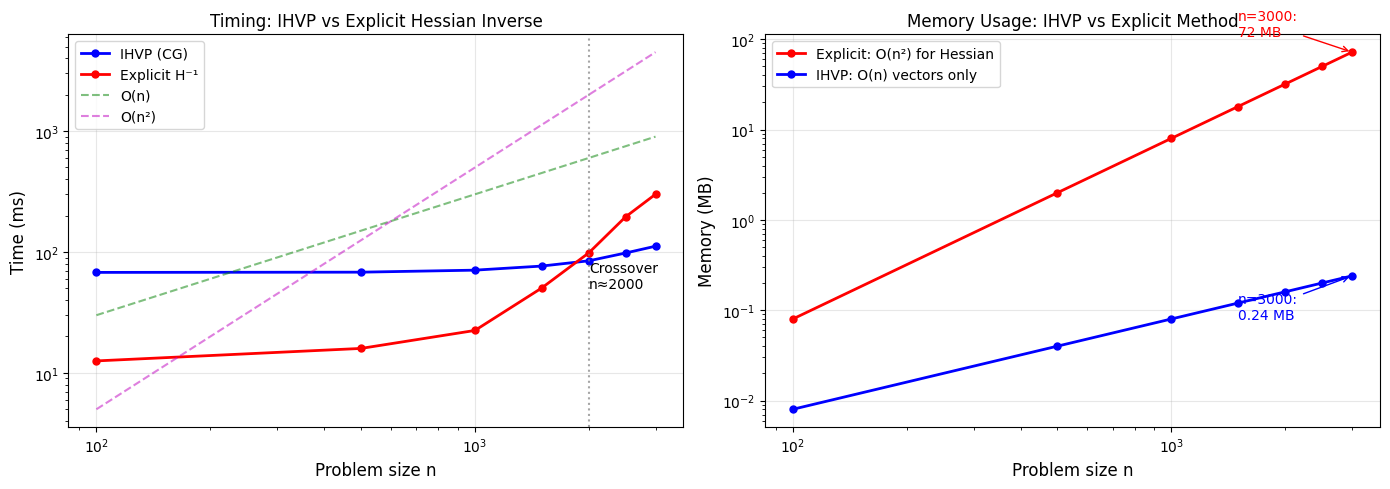


Memory comparison at n=3000:
  Explicit method needs: 72.0 MB (to store Hessian)
  IHVP method needs:     0.24 MB (just vectors)
  Memory savings:        300x less memory with IHVP


In [9]:
# Visualize timing and memory comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns = [r['n'] for r in results]
times_ihvp = [r['time_ihvp'] * 1000 for r in results]
times_explicit = [r['time_explicit'] * 1000 if r['time_explicit'] else None for r in results]
mem_hessian = [r['mem_hessian_theory'] / 1e6 for r in results]  # MB

# Plot 1: Timing comparison
ax1 = axes[0]
ax1.loglog(ns, times_ihvp, 'b.-', markersize=10, linewidth=2, label='IHVP (CG)')
valid_explicit = [(n, t) for n, t in zip(ns, times_explicit) if t is not None]
if valid_explicit:
    ax1.loglog([x[0] for x in valid_explicit], [x[1] for x in valid_explicit], 
               'r.-', markersize=10, linewidth=2, label='Explicit H⁻¹')

# Add reference lines for scaling
n_ref = jnp.array([100, 3000])
ax1.loglog(n_ref, 30 * (n_ref / 100)**1, 'g--', alpha=0.5, label='O(n)')
ax1.loglog(n_ref, 5 * (n_ref / 100)**2, 'm--', alpha=0.5, label='O(n²)')

ax1.set_xlabel('Problem size n', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.set_title('Timing: IHVP vs Explicit Hessian Inverse', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark crossover point
crossover_n = None
for i, r in enumerate(results):
    if r['time_explicit'] and r['time_explicit'] > r['time_ihvp']:
        crossover_n = r['n']
        break
if crossover_n:
    ax1.axvline(x=crossover_n, color='gray', linestyle=':', alpha=0.7)
    ax1.annotate(f'Crossover\nn≈{crossover_n}', xy=(crossover_n, 50), fontsize=10)

# Plot 2: Memory comparison
ax2 = axes[1]

# IHVP memory: O(n) - just vectors
mem_ihvp_theory = [8 * n * 10 / 1e6 for n in ns]  # ~10 vectors of size n

ax2.loglog(ns, mem_hessian, 'r.-', markersize=10, linewidth=2, label='Explicit: O(n²) for Hessian')
ax2.loglog(ns, mem_ihvp_theory, 'b.-', markersize=10, linewidth=2, label='IHVP: O(n) vectors only')

ax2.set_xlabel('Problem size n', fontsize=12)
ax2.set_ylabel('Memory (MB)', fontsize=12)
ax2.set_title('Memory Usage: IHVP vs Explicit Method', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add annotations for largest size
max_idx = -1
ax2.annotate(f'n={ns[max_idx]}:\n{mem_hessian[max_idx]:.0f} MB', 
             xy=(ns[max_idx], mem_hessian[max_idx]), xytext=(ns[max_idx]//2, mem_hessian[max_idx]*1.5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')
ax2.annotate(f'n={ns[max_idx]}:\n{mem_ihvp_theory[max_idx]:.2f} MB', 
             xy=(ns[max_idx], mem_ihvp_theory[max_idx]), xytext=(ns[max_idx]//2, mem_ihvp_theory[max_idx]/3),
             arrowprops=dict(arrowstyle='->', color='blue'),
             fontsize=10, color='blue')

plt.tight_layout()
plt.show()

# Print memory savings
print(f"\nMemory comparison at n={ns[-1]}:")
print(f"  Explicit method needs: {mem_hessian[-1]:.1f} MB (to store Hessian)")
print(f"  IHVP method needs:     {mem_ihvp_theory[-1]:.2f} MB (just vectors)")
print(f"  Memory savings:        {mem_hessian[-1] / mem_ihvp_theory[-1]:.0f}x less memory with IHVP")

## 6. Application: Newton-CG for Large-Scale Optimization

For real applications, we combine:
- **Line search**: Ensure sufficient decrease
- **Trust region**: Limit step size
- **Preconditioning**: Accelerate CG convergence

In [10]:
def newton_cg_optimize(f, x0, maxiter=100, gtol=1e-6, verbose=True):
    """Newton-CG optimizer with backtracking line search.
    
    Args:
        f: Objective function
        x0: Initial point
        maxiter: Maximum iterations
        gtol: Gradient tolerance for convergence
        verbose: Print progress
    
    Returns:
        x: Optimized point
        info: Optimization info
    """
    x = x0
    history = {'f': [], 'gnorm': []}
    
    for i in range(maxiter):
        g = grad(f)(x)
        gnorm = jnp.linalg.norm(g)
        fval = f(x)
        
        history['f'].append(float(fval))
        history['gnorm'].append(float(gnorm))
        
        if verbose and i % 5 == 0:
            print(f"Iter {i:3d}: f = {fval:.6e}, ||g|| = {gnorm:.6e}")
        
        if gnorm < gtol:
            if verbose:
                print(f"Converged at iteration {i}")
            break
        
        # Newton direction via CG
        direction = -ihvp(f, x, g)
        
        # Backtracking line search
        alpha = 1.0
        c = 1e-4  # Armijo constant
        rho = 0.5  # Backtracking factor
        
        while f(x + alpha * direction) > fval + c * alpha * jnp.dot(g, direction):
            alpha *= rho
            if alpha < 1e-10:
                break
        
        x = x + alpha * direction
    
    return x, history


# Optimize Rosenbrock
x0 = jnp.array([-1.5, 1.5])
x_opt, history = newton_cg_optimize(rosenbrock, x0, maxiter=50, verbose=True)

print(f"\nOptimum: {x_opt}")
print(f"f(x*) = {rosenbrock(x_opt):.2e}")

Iter   0: f = 6.250000e+01, ||g|| = 4.790877e+02
Iter   5: f = 2.883150e+00, ||g|| = 6.902294e+00
Iter  10: f = 9.529114e-01, ||g|| = 1.228755e+01
Iter  15: f = 6.708411e-02, ||g|| = 7.014664e-01
Iter  20: f = 1.993389e-05, ||g|| = 1.210767e-01
Converged at iteration 23

Optimum: [1. 1.]
f(x*) = 9.48e-24


## Summary

| Concept | Formula | JAX Implementation |
|---------|---------|--------------------|
| Gradient | ∇f | `grad(f)(x)` |
| Hessian-vector product | H·v | `jvp(grad(f), (x,), (v,))[1]` |
| Inverse Hessian-vector product | H⁻¹·v | `cg(hvp_op, v)` |
| Newton step | -H⁻¹·∇f | `-ihvp(f, x, grad(f)(x))` |

**Key takeaways:**
1. CG solves linear systems using only matrix-vector products
2. IHVP computes H⁻¹·v in O(kn) vs O(n³) for explicit inversion
3. Newton-CG enables second-order optimization for large problems
4. All operations are differentiable in JAX!